Total pairs in dataset: 128


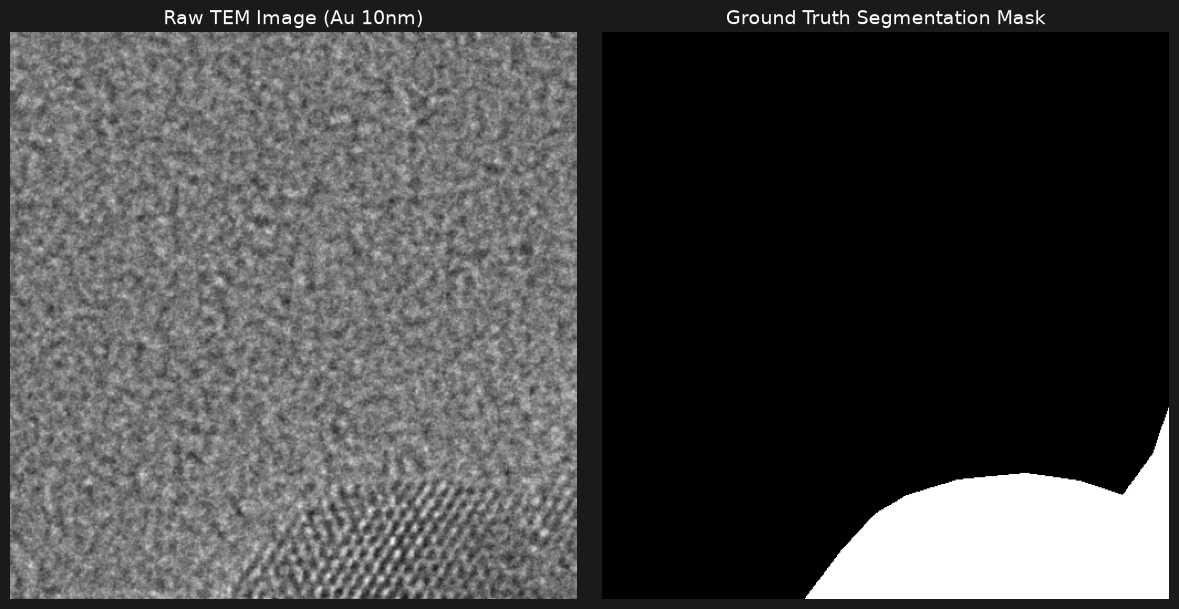

In [1]:
import sys
import matplotlib.pyplot as plt

# Add the project root to the path so we can import our custom dataset class
sys.path.append('..')
from src.data.dataset import LBNLTEMDataset

# Define relative paths from the notebooks folder to the raw data
images_path = "../data/raw/au_10nm_images.h5"
masks_path = "../data/raw/au_10nm_labels.h5"

# Initialize your ingestion engine
dataset = LBNLTEMDataset(images_path=images_path, masks_path=masks_path)
print(f"Total pairs in dataset: {len(dataset)}")

# Fetch the very first image/mask pair
img_tensor, mask_tensor = dataset[0]

# PyTorch tensors are [C, H, W]. Matplotlib expects 2D arrays [H, W] for grayscale.
img_np = img_tensor.squeeze().numpy()
mask_np = mask_tensor.squeeze().numpy()

# Plot the physics data next to the human labels
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(img_np, cmap='gray')
ax[0].set_title("Raw TEM Image (Au 10nm)", fontsize=14)
ax[0].axis('off')

ax[1].imshow(mask_np, cmap='gray')
ax[1].set_title("Ground Truth Segmentation Mask", fontsize=14)
ax[1].axis('off')

plt.tight_layout()
plt.show()